In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
import torch
import gc
import warnings

In [2]:
test_csv_path = 'sberquad_test.csv'

In [3]:
def calculate_ndcg_at_k(ranked_list, relevant_docs, k=10):
    dcg = 0.0
    idcg = 0.0
    
    for i, doc_id in enumerate(ranked_list[:k]):
        if doc_id in relevant_docs:
            dcg += 1.0 / np.log2(i + 2)
            
    num_relevant = len(relevant_docs)
    for i in range(min(num_relevant, k)):
        idcg += 1.0 / np.log2(i + 2)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg

In [4]:
def calculate_mrr(ranked_list, relevant_docs):
    for i, doc_id in enumerate(ranked_list):
        if doc_id in relevant_docs:
            return 1.0 / (i + 1)
    return 0.0

In [5]:
def calculate_map_at_k(ranked_list, relevant_docs, k=10):
    if len(relevant_docs) == 0:
        return 0.0
    
    score = 0.0
    num_relevant_found = 0
    
    for i, doc_id in enumerate(ranked_list[:k]):
        if doc_id in relevant_docs:
            num_relevant_found += 1
            precision_at_i = num_relevant_found / (i + 1)
            score += precision_at_i
            
    return score / min(len(relevant_docs), k)

In [6]:
def calculate_recall_at_k(ranked_list, relevant_docs, k=10):
    if len(relevant_docs) == 0:
        return 0.0
    
    found = sum(1 for doc_id in ranked_list[:k] if doc_id in relevant_docs)
    return found / len(relevant_docs)

In [7]:
def evaluate_model(model, model_name, corpus_map, queries_map, test_qrels):
    print(f"\n Оцениваем: {model_name}")
    
    corpus_ids = list(corpus_map.keys())
    corpus_texts = [f"passage: {corpus_map[doc_id]}" for doc_id in corpus_ids]
    
    print("  Кодирование корпуса документов...")
    corpus_embeddings = model.encode(
        corpus_texts,
        convert_to_tensor=True,
        show_progress_bar=True,
        batch_size=32
    )
    
    scores = {
        'NDCG@10': [], 'NDCG@5': [],
        'MRR': [],
        'MAP@10': [],
        'Recall@10': [], 'Recall@5': []
    }
    
    print("  Обработка запросов и ранжирование...")
    
    
    query_ids = list(queries_map.keys())
    query_texts = [f"query: {queries_map[qid]}" for qid in query_ids]
    
    query_embeddings = model.encode(
        query_texts, 
        convert_to_tensor=True, 
        show_progress_bar=True,
        batch_size=32
    )
    
    print("  Вычисление сходства...")
    cosine_scores = util.cos_sim(query_embeddings, corpus_embeddings)
    
    for i, query_id in enumerate(tqdm(query_ids, desc="Metrics calc")):
        top_results = torch.topk(cosine_scores[i], k=20) 
        ranked_indices = top_results.indices.cpu().tolist()
        
        ranked_doc_ids = [corpus_ids[idx] for idx in ranked_indices]
        relevant_docs = test_qrels[query_id] # Это set правильных doc_id
        
        scores['NDCG@10'].append(calculate_ndcg_at_k(ranked_doc_ids, relevant_docs, k=10))
        scores['NDCG@5'].append(calculate_ndcg_at_k(ranked_doc_ids, relevant_docs, k=5))
        scores['MRR'].append(calculate_mrr(ranked_doc_ids, relevant_docs))
        scores['MAP@10'].append(calculate_map_at_k(ranked_doc_ids, relevant_docs, k=10))
        scores['Recall@10'].append(calculate_recall_at_k(ranked_doc_ids, relevant_docs, k=10))
        scores['Recall@5'].append(calculate_recall_at_k(ranked_doc_ids, relevant_docs, k=5))

    avg_results = {k: np.mean(v) for k, v in scores.items()}
    return avg_results

In [8]:
print(" Загрузка тестовых данных...")
df_test = pd.read_csv('sberquad_test.csv')

corpus_map = dict(zip(df_test['doc_id'], df_test['passage']))
queries_map = dict(zip(df_test['query_id'], df_test['query']))

test_qrels = {}
for _, row in df_test.iterrows():
    qid = row['query_id']
    did = row['doc_id']
    if qid not in test_qrels:
        test_qrels[qid] = set()
    test_qrels[qid].add(did)

print(f"  Запросов: {len(queries_map)}")
print(f"  Документов: {len(corpus_map)}")

 Загрузка тестовых данных...
  Запросов: 9066
  Документов: 9066


In [11]:
models_paths = {
    "Baseline": "models/sberquad_baseline_0952",       
    "Curriculum": "models/sberquad_curriculum_1032/final_model"   
}

all_results = []

for name, path in models_paths.items():
    try:
        model = SentenceTransformer(path)
        metrics = evaluate_model(model, name, corpus_map, queries_map, test_qrels)
        metrics['Model'] = name
        all_results.append(metrics)
        
        del model
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"Ошибка с моделью {name}: {e}")

The tokenizer you are loading from 'models/sberquad_baseline_0952' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.



 Оцениваем: Baseline
  Кодирование корпуса документов...


Batches:   0%|          | 0/284 [00:00<?, ?it/s]

  Обработка запросов и ранжирование...


Batches:   0%|          | 0/284 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/284 [00:00<?, ?it/s]

  Обработка запросов и ранжирование...


Batches:   0%|          | 0/284 [00:00<?, ?it/s]

  Вычисление сходства...


Metrics calc: 100%|██████████████████████████████████████████████████████████████| 9066/9066 [00:01<00:00, 7963.17it/s]



Итоговое сравнение:
Model     Baseline Curriculum Growth (%)
NDCG@10     0.7177     0.7214     +0.52%
NDCG@5      0.7009     0.7050     +0.59%
MRR         0.6527     0.6560     +0.50%
MAP@10      0.6505     0.6539     +0.52%
Recall@10   0.9215     0.9262     +0.51%
Recall@5    0.8700     0.8758     +0.67%


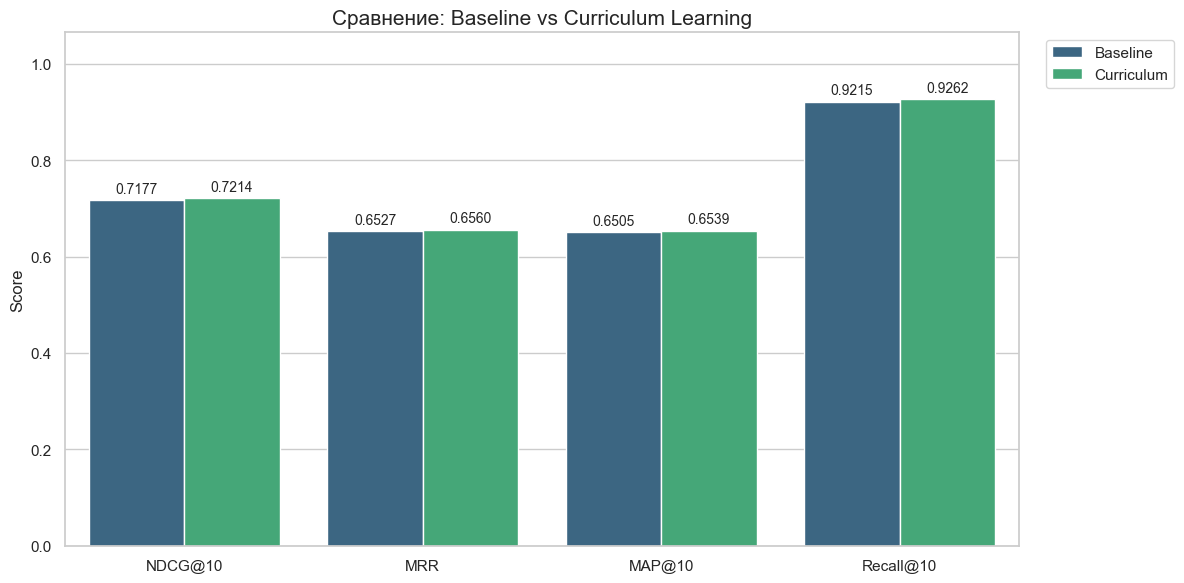

In [17]:
df_res = pd.DataFrame(all_results)
    
print("\nИтоговое сравнение:")
    
df_table = df_res.set_index('Model').T
    
if 'Baseline' in df_table.columns and 'Curriculum' in df_table.columns:
    base = df_table['Baseline']
    curr = df_table['Curriculum']
        
    df_table['Growth (%)'] = ((curr - base) / base) * 100
        
    df_print = df_table.copy()
        
    df_print['Baseline'] = df_print['Baseline'].apply(lambda x: f"{x:.4f}")
    df_print['Curriculum'] = df_print['Curriculum'].apply(lambda x: f"{x:.4f}")
        
    df_print['Growth (%)'] = df_print['Growth (%)'].apply(lambda x: f"{x:+.2f}%")
        
    print(df_print)
else:
    print(df_table)

metrics_to_plot = ['NDCG@10', 'MRR', 'MAP@10', 'Recall@10']
df_melted = df_res.melt(id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Score")
    
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
    
chart = sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="viridis"
)
    
plt.title("Сравнение: Baseline vs Curriculum Learning", fontsize=15)
plt.ylim(0, df_melted['Score'].max() * 1.15)
plt.xlabel("")
plt.ylabel("Score")
    
for container in chart.containers:
    chart.bar_label(container, fmt='%.4f', padding=3, fontsize=10)
        
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()